In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize

In [60]:
df = load_wine(as_frame=True)
df = df.frame
df.head(70)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,12.37,1.21,2.56,18.1,98.0,2.42,2.65,0.37,2.08,4.60,1.19,2.30,678.0,1
66,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0,1
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1
68,13.34,0.94,2.36,17.0,110.0,2.53,1.30,0.55,0.42,3.17,1.02,1.93,750.0,1


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [62]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

In [63]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


| Колонка                      | Перевод                      | Описание                                                    |
| ---------------------------- | ---------------------------- | ----------------------------------------------------------- |
| alcohol                      | Алкоголь                     | Содержание спирта в вине (%)                                |
| malic_acid                   | Молочная кислота             | Содержание кислоты, влияет на вкус                          |
| ash                          | Зола                         | Минеральные вещества после сгорания вина                    |
| alcalinity_of_ash            | Щёлочность золы              | Способность золы нейтрализовать кислоту                     |
| magnesium                    | Магний                       | Минеральный элемент (мг/л)                                  |
| total_phenols                | Общие фенолы                 | Влияют на вкус и антиоксидантные свойства                   |
| flavanoids                   | Флавоноиды                   | Антиоксиданты, влияют на цвет и вкус                        |
| nonflavanoid_phenols         | Нефлавоноидные фенолы        | Другие фенолы, не относящиеся к флавоноидам                 |
| proanthocyanins              | Проантоцианины               | Влияют на вкус, цвет и терпкость                            |
| color_intensity              | Интенсивность цвета          | Насколько тёмный или насыщенный цвет вина                   |
| hue                          | Оттенок                      | Соотношение красного/жёлтого оттенка вина                   |
| od280/od315_of_diluted_wines | OD280/OD315 разбавленных вин | Показатель фенольного состава, измеряется спектрофотометром |
| proline                      | Пролин                       | Аминокислота, связана с качеством и сортом винограда        |
| target                       | Целевая переменная           | Тип вина: 0, 1 или 2                                        |


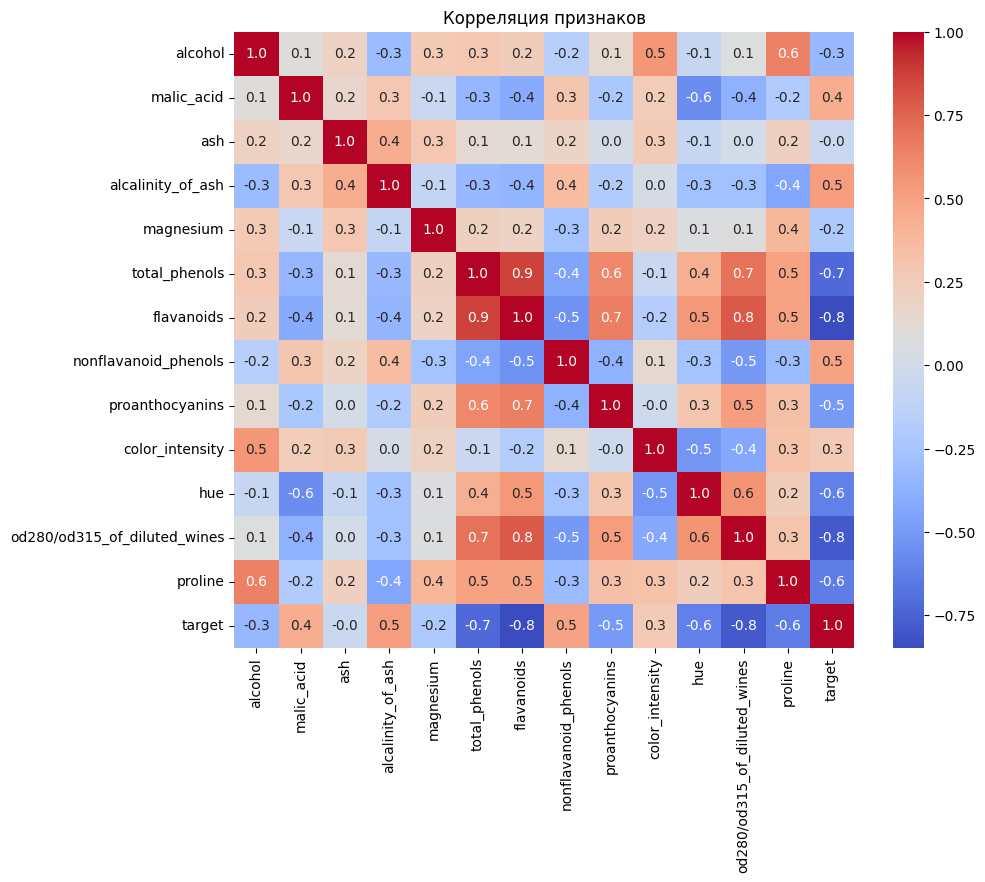

In [64]:

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Корреляция признаков")
plt.show()

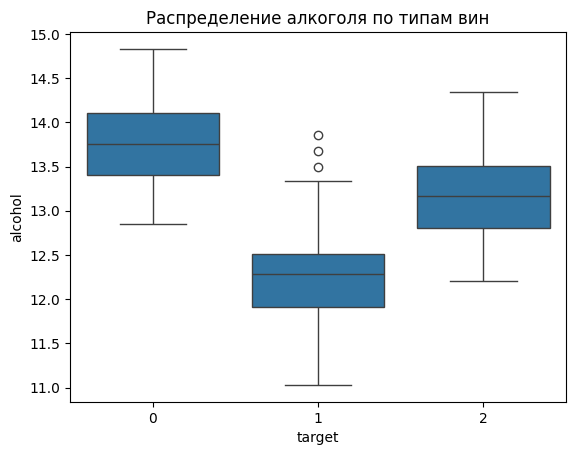

In [65]:
sns.boxplot(x='target', y='alcohol', data=df)
plt.title("Распределение алкоголя по типам вин")
plt.show()

C:\Users\baika\AppData\Local\Temp\ipykernel_2908\1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\baika\AppData\Local\Temp\ipykernel_2908\1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\baika\AppData\Local\Temp\ipykernel_2908\1934373683.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\baika\AppData\Local\Temp\ipykernel

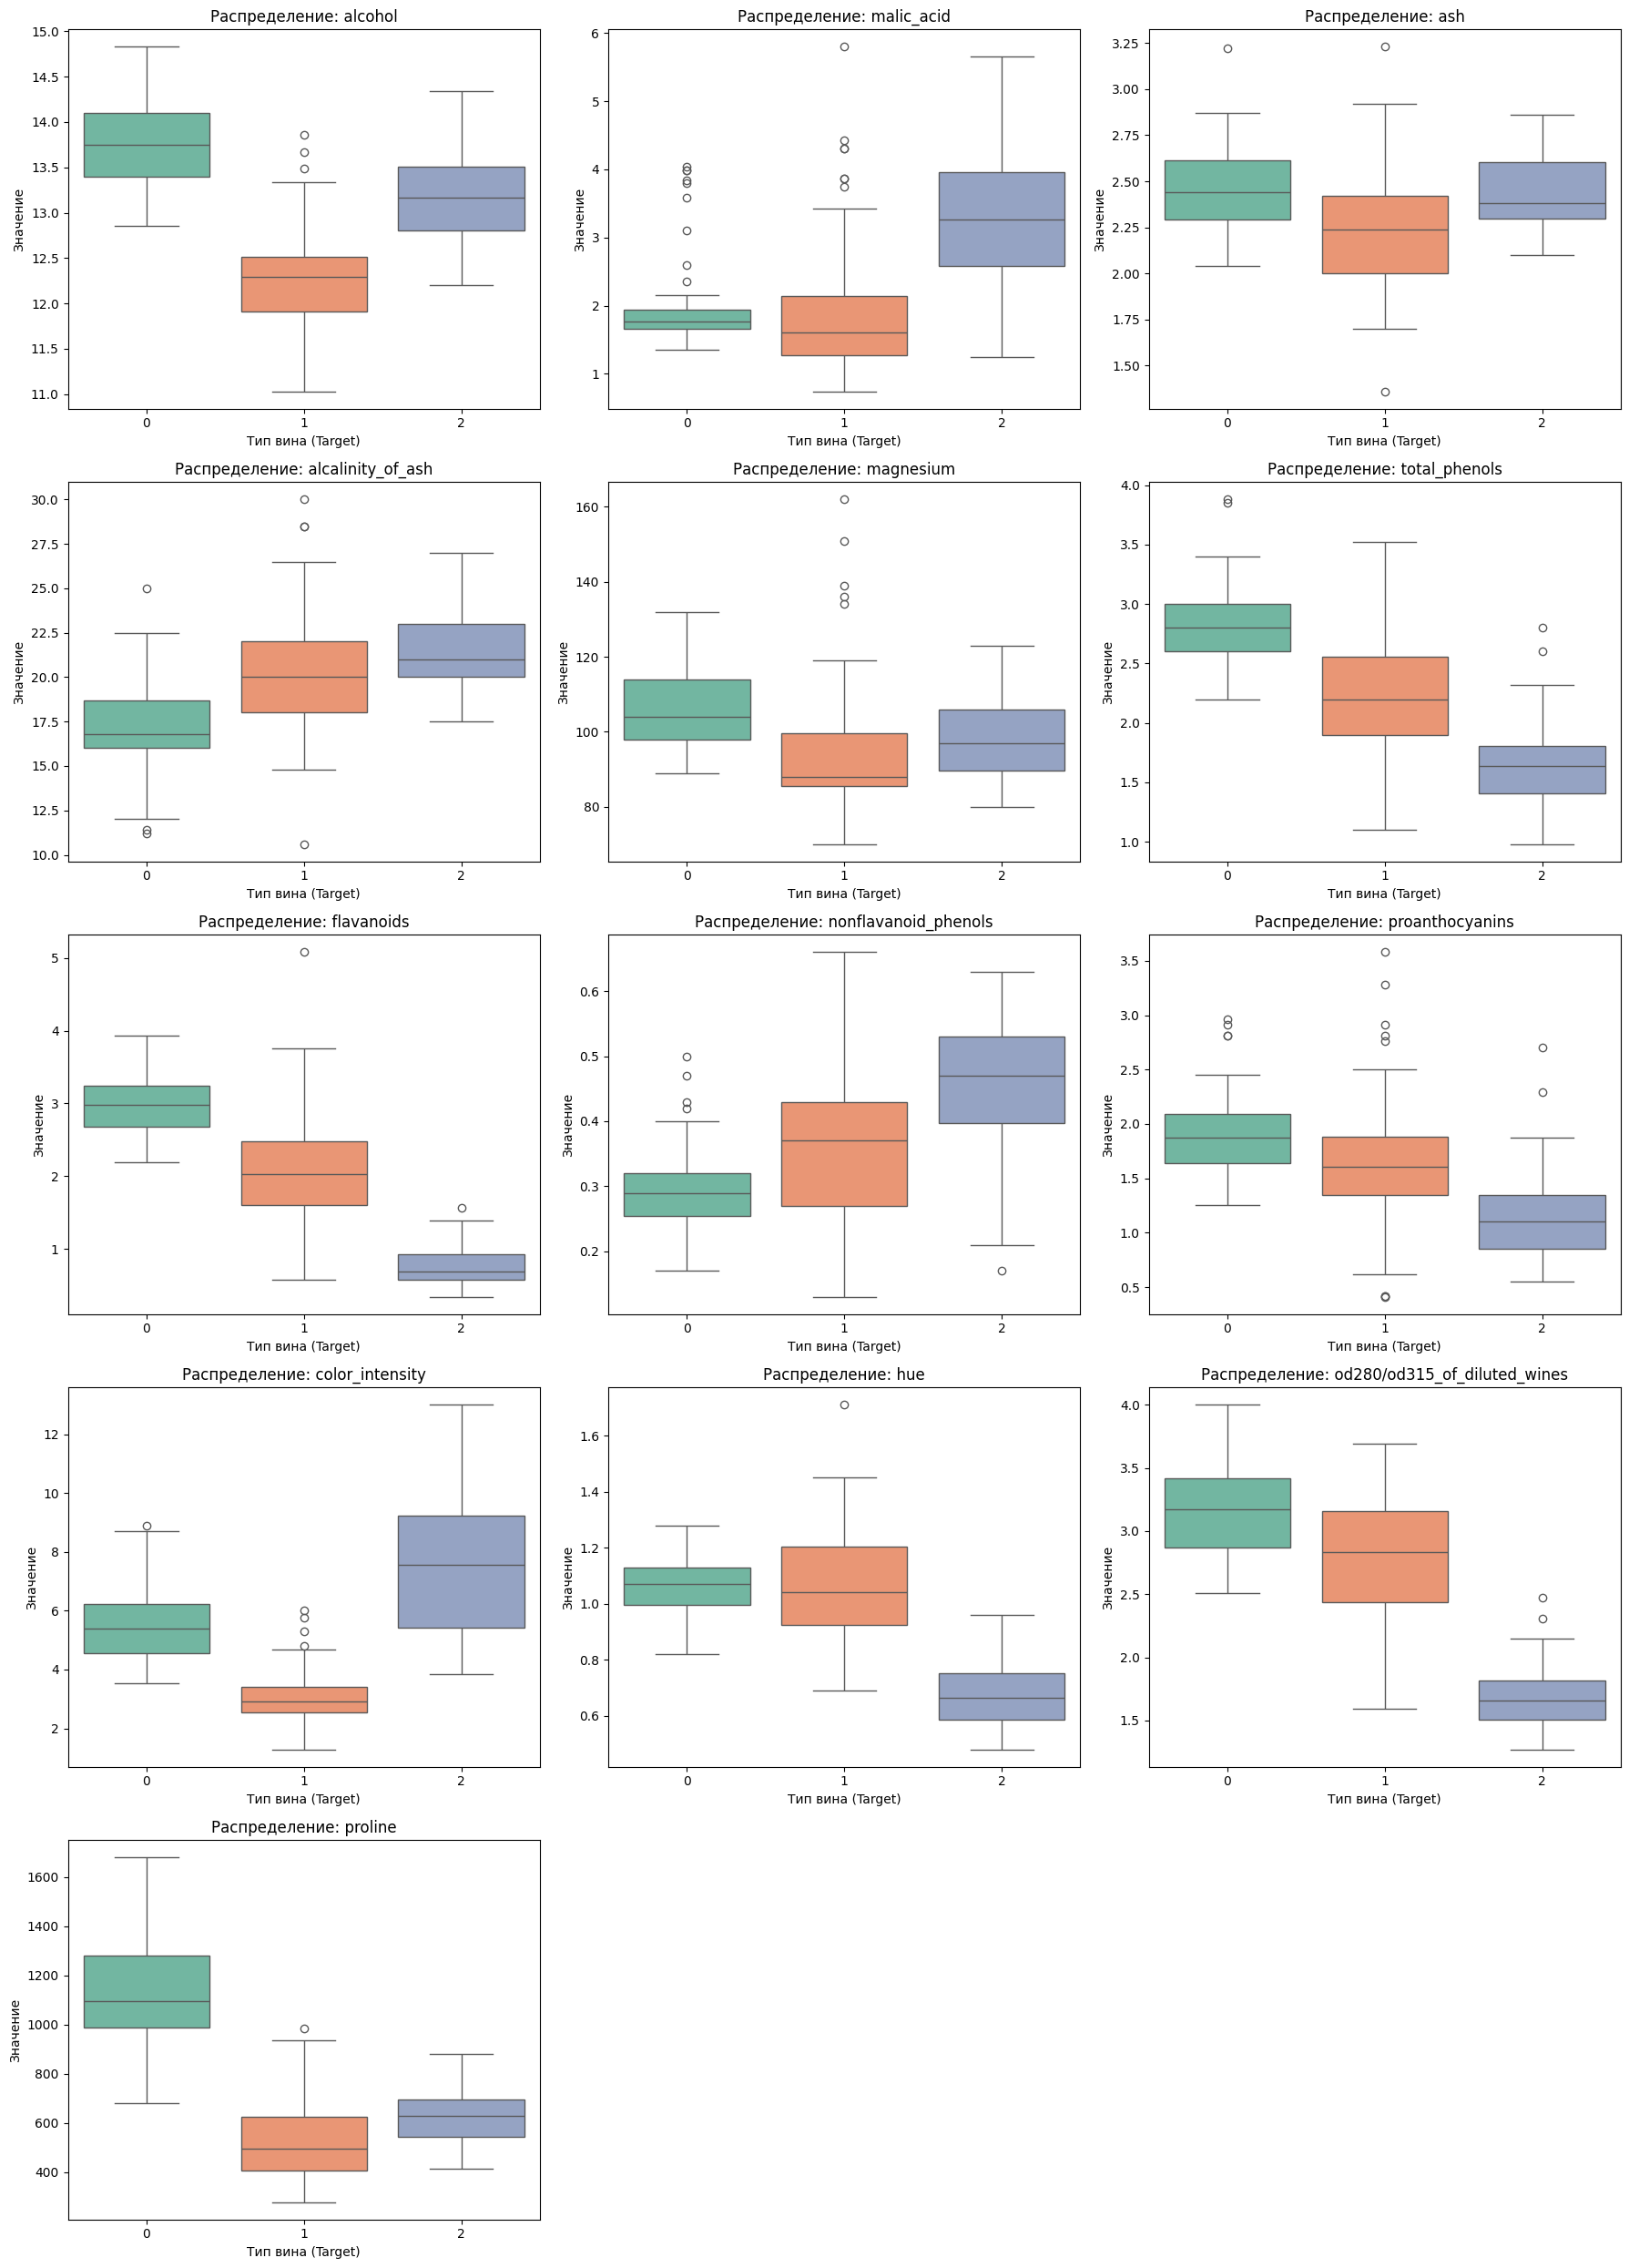

In [66]:
features = df.columns.drop('target')

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='target', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel('Тип вина (Target)')
    axes[i].set_ylabel('Значение')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt'}
Точность CV:      0.9232


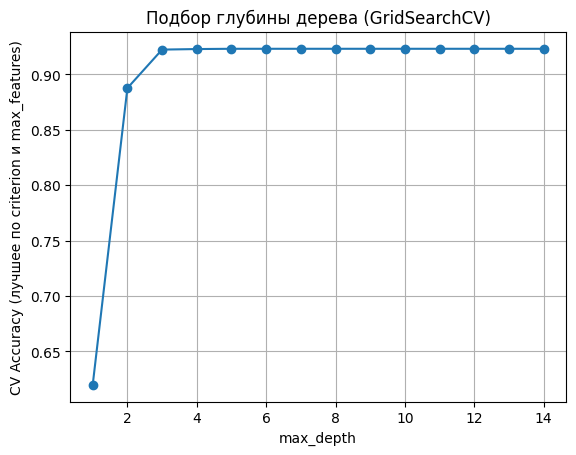

In [68]:
# --- Decision Tree: подбор параметров через GridSearchCV ---
# criterion: как считать "нечистоту" узла — gini или entropy
# max_features: сколько признаков рассматривать при каждом разбиении
param_grid_dt = {
    'max_depth':    list(range(1, 15)),
    'criterion':    ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Точность CV:      {grid_dt.best_score_:.4f}")

# График точности по глубине (усредняем по criterion и max_features)
import pandas as pd
results_df = pd.DataFrame(grid_dt.cv_results_)
depth_scores = results_df.groupby('param_max_depth')['mean_test_score'].max()

plt.plot(depth_scores.index, depth_scores.values, marker='o')
plt.xlabel("max_depth")
plt.ylabel("CV Accuracy (лучшее по criterion и max_features)")
plt.title("Подбор глубины дерева (GridSearchCV)")
plt.grid()
plt.show()

In [69]:
# Берём лучшую модель из GridSearchCV напрямую
dt = grid_dt.best_estimator_
dt_pred = dt.predict(X_test)

print(f"Точность Decision Tree: {accuracy_score(y_test, dt_pred):.4f}")

Точность Decision Tree: 0.9444


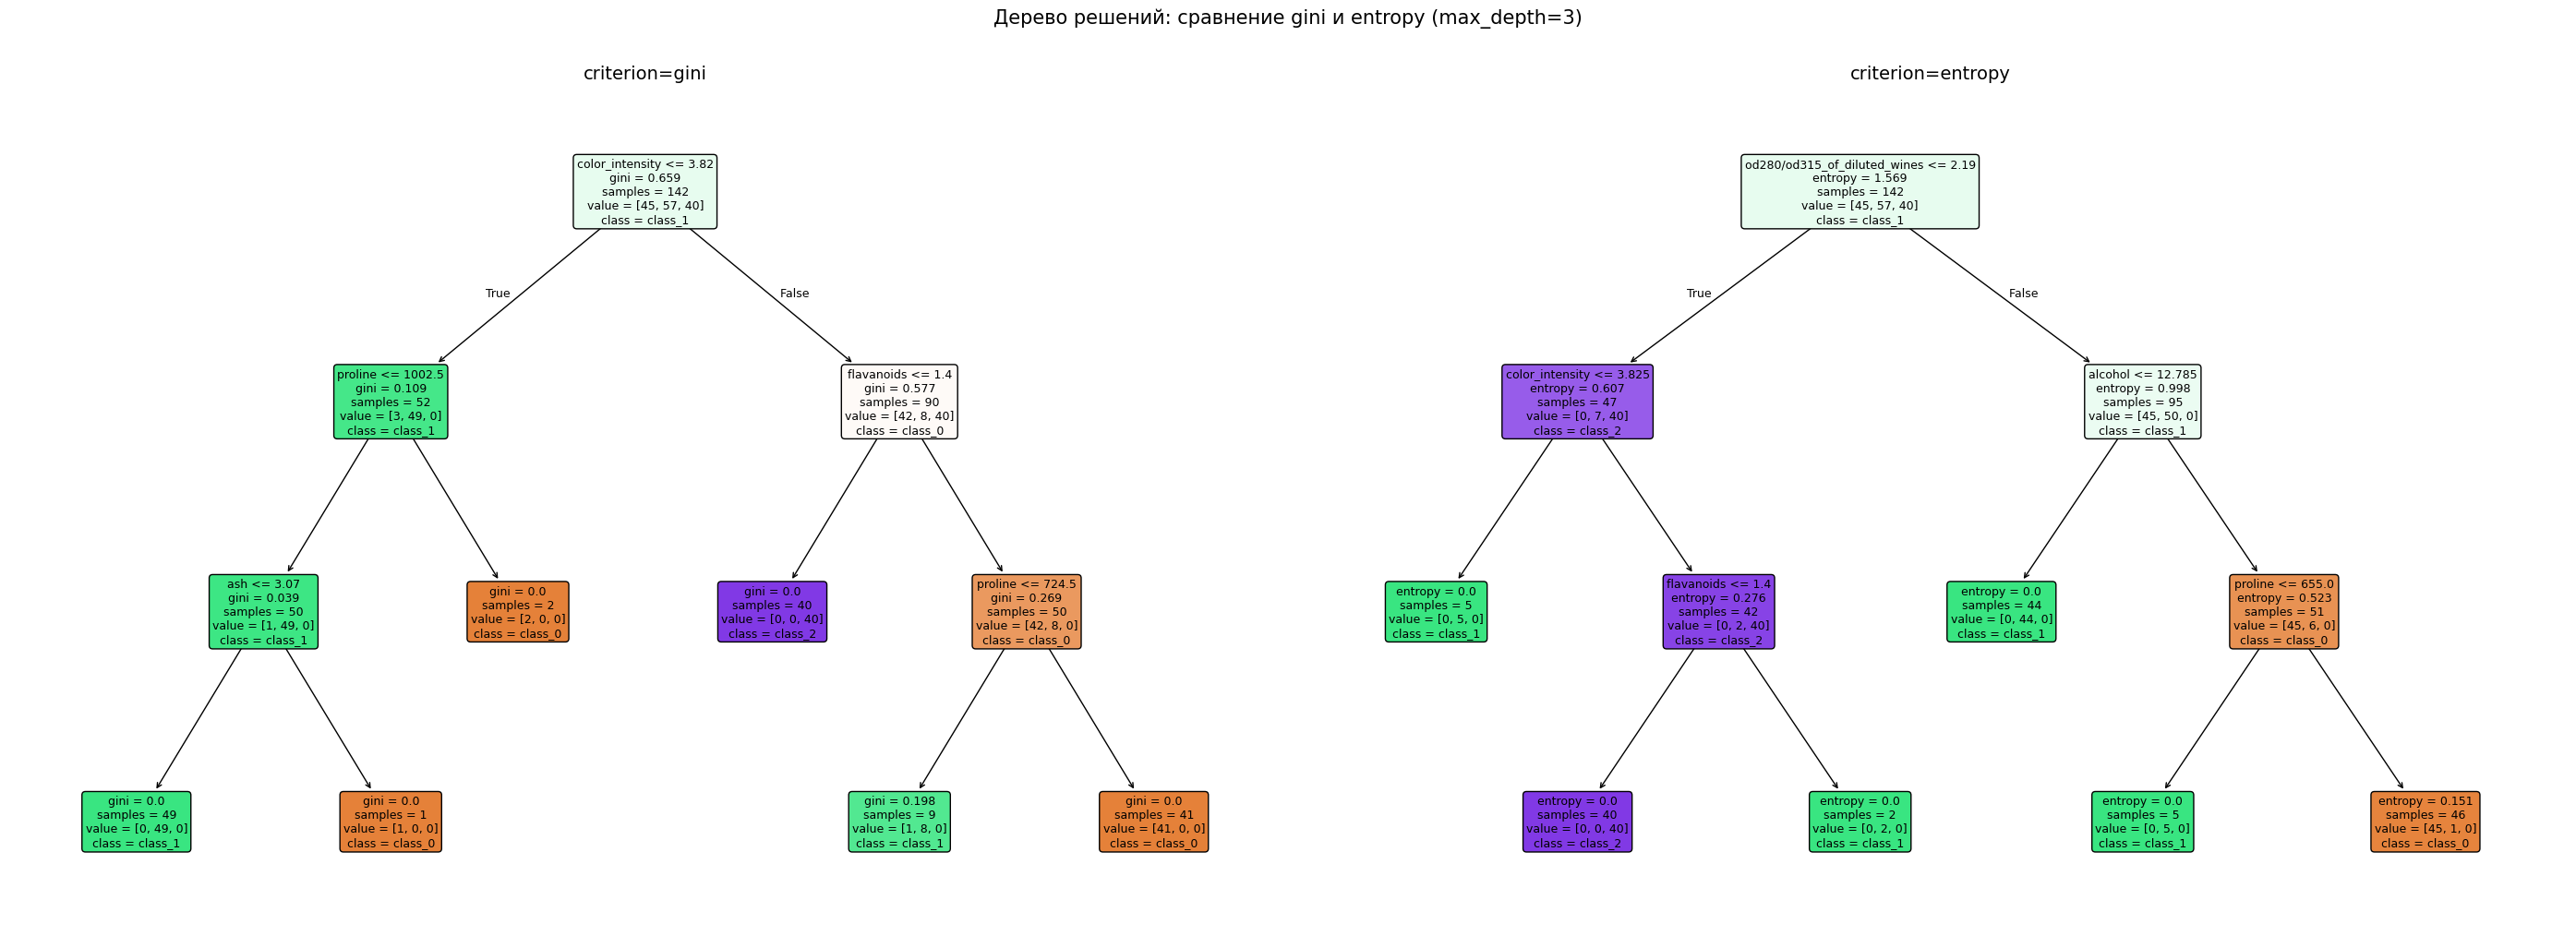

In [70]:
# Визуализация дерева: gini vs entropy (глубина 3 для читаемости)
target_names = list(load_wine().target_names)

fig, axes = plt.subplots(1, 2, figsize=(28, 10))

for ax, criterion in zip(axes, ['gini', 'entropy']):
    dt_vis = DecisionTreeClassifier(max_depth=3, criterion=criterion, random_state=42)
    dt_vis.fit(X_train, y_train)
    plot_tree(
        dt_vis,
        feature_names=list(X.columns),
        class_names=target_names,
        filled=True,       # закрашивает узлы цветом класса
        rounded=True,      # скруглённые углы
        fontsize=9,
        ax=ax
    )
    ax.set_title(f'criterion={criterion}', fontsize=14)

plt.suptitle('Дерево решений: сравнение gini и entropy (max_depth=3)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14
           2       0.88      0.88      0.88         8

    accuracy                           0.94        36
   macro avg       0.94      0.93      0.93        36
weighted avg       0.95      0.94      0.94        36



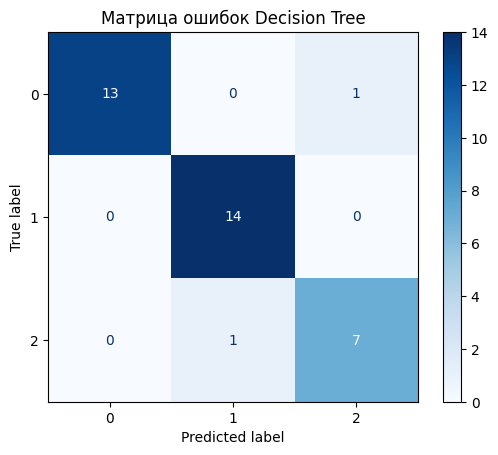

In [48]:
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Матрица ошибок Decision Tree')
plt.show()

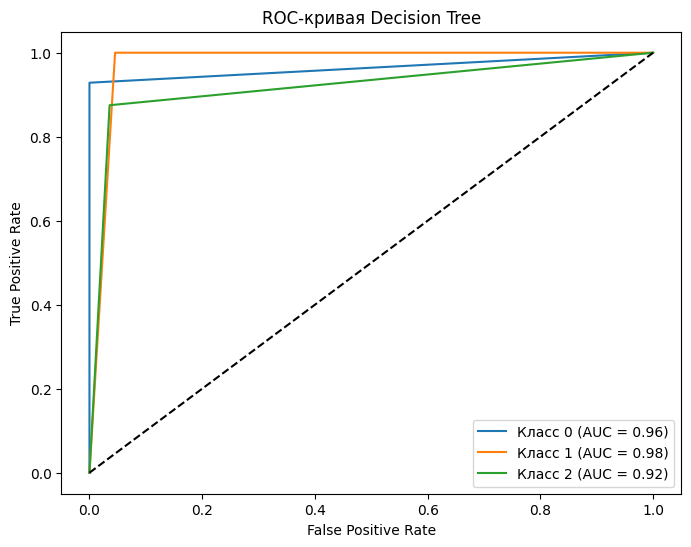

In [49]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score_dt = dt.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Класс {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Decision Tree')
plt.legend(loc="lower right")
plt.show()

In [50]:
# Оптимальный порог для каждого класса (метод Юдена: максимум TPR - FPR)
print("Оптимальные пороги для Decision Tree:")
for i in range(3):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score_dt[:, i])
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    print(f"  Класс {i}: порог = {thresholds[best_idx]:.2f}  (TPR={tpr[best_idx]:.2f}, FPR={fpr[best_idx]:.2f})")

Оптимальные пороги для Decision Tree:
  Класс 0: порог = 1.00  (TPR=0.93, FPR=0.00)
  Класс 1: порог = 1.00  (TPR=1.00, FPR=0.05)
  Класс 2: порог = 1.00  (TPR=0.88, FPR=0.04)


## Random Forest

Лучшее количество деревьев: 100, точность CV: 0.9786


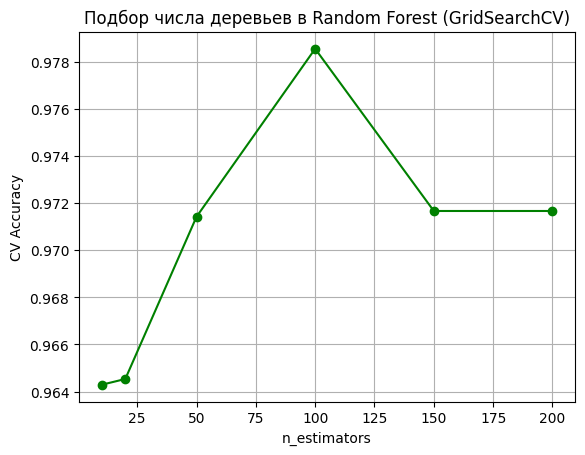

In [51]:
# --- Random Forest: подбор оптимального числа деревьев через GridSearchCV ---
param_grid_rf = {'n_estimators': [10, 20, 50, 100, 150, 200]}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_n = grid_rf.best_params_['n_estimators']
print(f"Лучшее количество деревьев: {best_n}, точность CV: {grid_rf.best_score_:.4f}")

# График точности по числу деревьев
cv_results_rf = grid_rf.cv_results_
plt.plot(param_grid_rf['n_estimators'], cv_results_rf['mean_test_score'], marker='o', color='green')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Подбор числа деревьев в Random Forest (GridSearchCV)")
plt.grid()
plt.show()

In [52]:
# Берём лучшую модель из GridSearchCV напрямую
rf = grid_rf.best_estimator_
rf_pred = rf.predict(X_test)

print(f"Точность Random Forest: {accuracy_score(y_test, rf_pred):.4f}")

Точность Random Forest: 1.0000


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



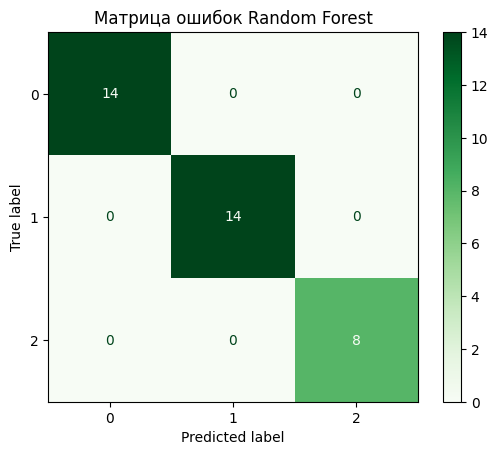

In [53]:
print(classification_report(y_test, rf_pred))

cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Greens')
plt.title('Матрица ошибок Random Forest')
plt.show()

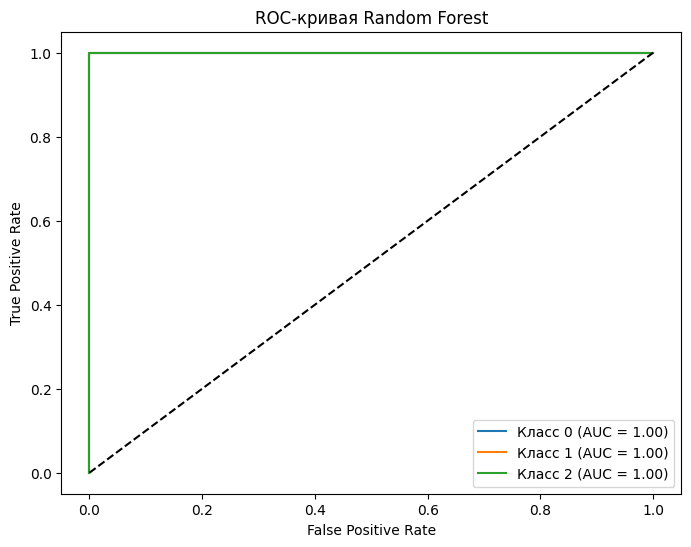

In [54]:
y_score_rf = rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Класс {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая Random Forest')
plt.legend(loc="lower right")
plt.show()

In [55]:
# Оптимальный порог для каждого класса (Random Forest)
print("Оптимальные пороги для Random Forest:")
for i in range(3):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    print(f"  Класс {i}: порог = {thresholds[best_idx]:.2f}  (TPR={tpr[best_idx]:.2f}, FPR={fpr[best_idx]:.2f})")

Оптимальные пороги для Random Forest:
  Класс 0: порог = 0.65  (TPR=1.00, FPR=0.00)
  Класс 1: порог = 0.61  (TPR=1.00, FPR=0.00)
  Класс 2: порог = 0.72  (TPR=1.00, FPR=0.00)


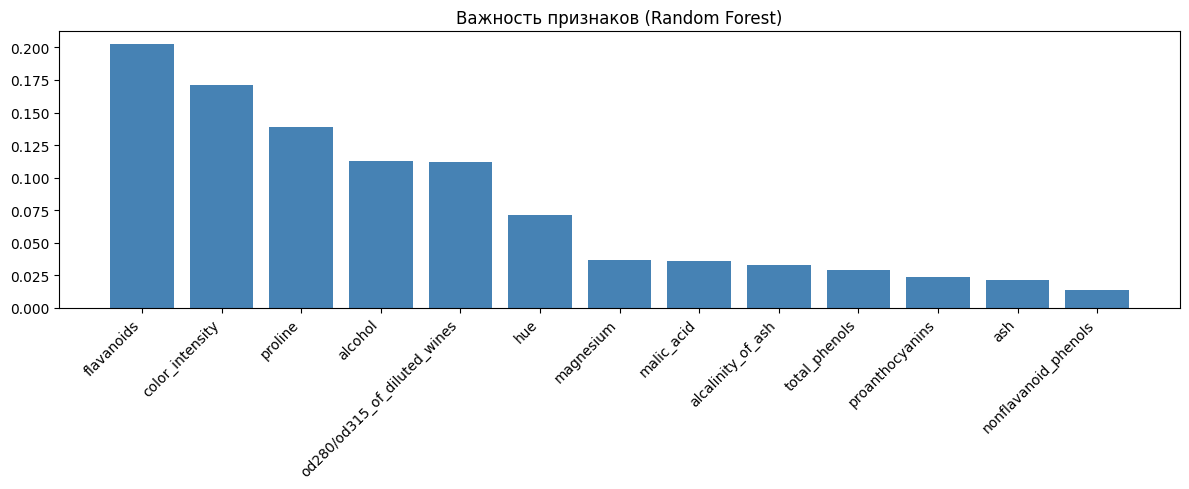

Самый важный признак: flavanoids  (важность = 0.2023)


In [56]:
# Важность признаков по Random Forest
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha='right')
plt.title("Важность признаков (Random Forest)")
plt.tight_layout()
plt.show()

print(f"Самый важный признак: {feature_names[indices[0]]}  (важность = {importances[indices[0]]:.4f})")

## Precision vs Recall

Для классификации вин по сортам важнее **Precision (точность)**.

- Ошибка модели здесь — это неправильное определение сорта вина.
- Ложноположительный результат (модель говорит "это класс 0", а на самом деле класс 1) приводит к неправильной маркировке продукта.
- В производстве/торговле такая ошибка хуже, чем "не знаю к какому классу отнести" (низкий Recall).
- Поэтому приоритет: минимизировать ложные срабатывания → **Precision важнее**.

In [57]:
new_wine_data = [13.7, 1.8, 2.3, 16.0, 110.0, 2.5, 2.3, 0.3, 1.8, 5.2, 1.1, 3.2, 1000.0]
 
new_wine_array = np.array([new_wine_data])
new_wine_array

array([[1.37e+01, 1.80e+00, 2.30e+00, 1.60e+01, 1.10e+02, 2.50e+00,
        2.30e+00, 3.00e-01, 1.80e+00, 5.20e+00, 1.10e+00, 3.20e+00,
        1.00e+03]])

In [58]:
raw_data = load_wine()
target_names = raw_data.target_names

new_wine_df = pd.DataFrame([new_wine_data], columns=X.columns)

dt_pred_new = dt.predict(new_wine_df)
dt_proba_new = dt.predict_proba(new_wine_df)

rf_pred_new = rf.predict(new_wine_df)
rf_proba_new = rf.predict_proba(new_wine_df)

print(f"Decision Tree  — сорт: {target_names[dt_pred_new[0]]}, вероятности: {dt_proba_new[0]}")
print(f"Random Forest  — сорт: {target_names[rf_pred_new[0]]}, вероятности: {rf_proba_new[0]}")

Decision Tree  — сорт: class_0, вероятности: [1. 0. 0.]
Random Forest  — сорт: class_0, вероятности: [0.88 0.11 0.01]
